# 03 Universal hall-aware classical baseline

Этот ноутбук связывает ML‑оракул спроса с классическим оптимизатором расписаний (CP-SAT) на универсальном сценарии с учётом залов, слотов и фильмов. Это эталонный classical baseline перед постановкой QUBO/annealer.

В этом ноутбуке мы:

- Загружаем `train/validation/test` сплиты и модель `final_model.joblib`, строим объединённый `reference_df` со всем пулом фильмов.
- Генерируем универсальный hall-aware candidate set (`universal_candidate_df`): для каждого зала, временного слота и фильма, присутствующего в тренировочных данных, создаём возможный показ с полным набором признаков.
- Прогоняем кандидатов через ML-модель (`final_model`) и получаем `pred_occupancy_rate`, `pred_sold_tickets`, `pred_revenue`, которые служат стоимостной частью для оптимизации.
- Формируем и решаем CP-SAT‑задачу: бинарные переменные «выбран ли candidate», жёсткие ограничения по hall-overlap/формату/вместимости и мягкие бизнес‑штрафы (cross‑hall каннибализация и др.), цель — максимизация суммарной прогнозной выручки.
- Сравниваем разные конфигурации («hard» vs «soft») по бизнес‑метрике суммарной выручки и количеству выбранных сеансов, используя CP-SAT objective только как внутреннюю техническую величину.


## Навигация по ноутбуку

### Зачем нужен этот ноутбук
Этот ноутбук строит классический baseline для задачи расписания. Здесь ML-прогноз соединяется с hall-aware оптимизацией, формируется candidate set, считается predicted revenue и решается классическая постановка через CP-SAT.

### Что здесь самое важное
- Это главный baseline, с которым сравниваются с annealing- и QAOA-подходами.
- Физические ограничения по залам должны быть корректно заданы именно здесь, иначе сравнение с квантово-инспирированными методами будет нечестным.
- Из этого ноутбука сохраняются QUBO-артефакты, которые используются в notebook 04.

### Какие результаты здесь ключевые
- Таблица candidate shows с predicted revenue.
- Результаты classical schedule optimization.
- Сохранённые QUBO-артефакты: mapping переменных, sparse Q-матрица, scored candidate set.

### Как читать этот ноутбук
Считать этот ноутбук эталонной classical reference point проекта. Перед анализом annealing-результатов нужно проверить, какие ограничения здесь жёсткие, какие мягкие, и насколько итоговое расписание физически реализуемо.


In [1]:

from __future__ import annotations

from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import matplotlib.pyplot as plt
import pandas as pd

import boq_backend.solvers.cp_sat_solver as cp_sat_solver_module
importlib.reload(cp_sat_solver_module)
solve_cp_sat_schedule = cp_sat_solver_module.solve_cp_sat_schedule

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
MODEL_PATH = ARTIFACTS_DIR / 'final_model.joblib'

PROJECT_ROOT, MODEL_PATH


(PosixPath('/Users/mishatrubik/Desktop/QC/BOQ'),
 PosixPath('/Users/mishatrubik/Desktop/QC/BOQ/artifacts/final_model.joblib'))

In [2]:
DROP_COLUMNS = ['show_id', 'sold_tickets', 'occupancy_rate']

train_df = pd.read_csv(PROCESSED_DIR / 'train.csv', parse_dates=['show_datetime'])
val_df = pd.read_csv(PROCESSED_DIR / 'validation.csv', parse_dates=['show_datetime'])
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv', parse_dates=['show_datetime'])

for df in (train_df, val_df, test_df):
    df['release_date'] = pd.to_datetime(df['release_date']).dt.date

reference_df = pd.concat([train_df, val_df, test_df], axis=0, ignore_index=True)

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f'Model artifact not found: {MODEL_PATH}. '
        'Run notebook 02 to save final_model.joblib before executing notebook 03.'
    )

final_model = joblib.load(MODEL_PATH)

{
    'reference_rows': len(reference_df),
    'model_path': str(MODEL_PATH),
}

{'reference_rows': 898,
 'model_path': '/Users/mishatrubik/Desktop/QC/BOQ/artifacts/final_model.joblib'}

In [3]:
def score_candidates(model, candidate_df: pd.DataFrame) -> pd.DataFrame:
    scored = candidate_df.copy()
    X_candidates = scored.drop(columns=DROP_COLUMNS, errors='ignore')
    scored['pred_occupancy_rate'] = model.predict(X_candidates).clip(0.0, 1.0)
    scored['pred_sold_tickets'] = (scored['pred_occupancy_rate'] * scored['hall_capacity']).round().astype(int)
    scored['pred_revenue'] = scored['pred_sold_tickets'] * scored['base_price']
    return scored

## Universal hall-aware scenario

The candidate set below explicitly models the cinema, hall, start time, end time, format, capacity,
and the movie assigned to that hall-time placement. This is the level on which the classical solver operates.

In [4]:
def build_universal_candidate_dataframe(reference_df: pd.DataFrame) -> pd.DataFrame:
    movie_pool = (
        reference_df.sort_values(['movie_id', 'show_datetime'])
        .groupby('movie_id', as_index=False)
        .first()[['movie_id', 'genre', 'age_rating', 'runtime_min', 'release_date']]
    )

    movie_price_pool = (
        reference_df.groupby('movie_id', as_index=False)['base_price']
        .median()
        .rename(columns={'base_price': 'base_price_median'})
    )

    movie_pool = movie_pool.merge(movie_price_pool, on='movie_id', how='left')

    halls = [
        {'cinema_id': 'cinema_moscow_toy', 'hall_id': 'hall_small', 'hall_capacity': 90, 'format': '2D'},
        {'cinema_id': 'cinema_moscow_toy', 'hall_id': 'hall_large', 'hall_capacity': 180, 'format': 'IMAX'},
    ]
    slots = [
        {'slot_id': 's1', 'show_datetime': pd.Timestamp('2026-01-15 13:30:00'), 'hour_bucket': 'day'},
        {'slot_id': 's2', 'show_datetime': pd.Timestamp('2026-01-15 15:00:00'), 'hour_bucket': 'day'},
        {'slot_id': 's3', 'show_datetime': pd.Timestamp('2026-01-15 18:00:00'), 'hour_bucket': 'evening'},
        {'slot_id': 's4', 'show_datetime': pd.Timestamp('2026-01-15 20:00:00'), 'hour_bucket': 'evening'},
    ]

    rows = []
    for hall in halls:
        screening_counter = {movie_id: 0 for movie_id in movie_pool['movie_id']}
        for slot in slots:
            for movie in movie_pool.to_dict(orient='records'):
                screening_counter[movie['movie_id']] += 1
                runtime_bucket = 'short' if movie['runtime_min'] < 90 else ('medium' if movie['runtime_min'] <= 120 else 'long')
                rows.append({
                    'show_id': f"{hall['hall_id']}__{slot['slot_id']}__{movie['movie_id']}",
                    'slot_id': f"{hall['hall_id']}__{slot['slot_id']}",
                    'cinema_id': hall['cinema_id'],
                    'hall_id': hall['hall_id'],
                    'hall_capacity': hall['hall_capacity'],
                    'movie_id': movie['movie_id'],
                    'genre': movie['genre'],
                    'age_rating': movie['age_rating'],
                    'runtime_min': int(movie['runtime_min']),
                    'release_date': movie['release_date'],
                    'show_datetime': slot['show_datetime'],
                    'end_datetime': slot['show_datetime'] + pd.to_timedelta(int(movie['runtime_min']), unit='m'),
                    'format': hall['format'],
                    'base_price': float(movie['base_price_median']),
                    'sold_tickets': 0,
                    'occupancy_rate': 0.0,
                    'city': 'Moscow',
                    'day_of_week': slot['show_datetime'].dayofweek,
                    'is_weekend': False,
                    'hour_bucket': slot['hour_bucket'],
                    'month': slot['show_datetime'].month,
                    'holiday_flag': False,
                    'release_age_days': (slot['show_datetime'].date() - movie['release_date']).days,
                    'lead_time_days': 7.0,
                    'prime_time_flag': slot['hour_bucket'] == 'evening',
                    'runtime_bucket': runtime_bucket,
                    'screening_number_for_movie': screening_counter[movie['movie_id']],
                })
    return pd.DataFrame(rows)


universal_candidate_df = build_universal_candidate_dataframe(reference_df)
{
    'shape': universal_candidate_df.shape,
    'num_movies': universal_candidate_df['movie_id'].nunique(),
    'movies': sorted(universal_candidate_df['movie_id'].unique().tolist()),
}

{'shape': (32, 27),
 'num_movies': 4,
 'movies': ['movie_comedy_01',
  'movie_dune_2',
  'movie_family_01',
  'movie_horror_01']}

In [5]:
universal_candidate_scored_df = score_candidates(final_model, universal_candidate_df)
universal_candidate_scored_df[['show_id', 'hall_id', 'slot_id', 'movie_id', 'show_datetime', 'end_datetime', 'pred_occupancy_rate', 'pred_revenue']].head(12)

,show_id,hall_id,slot_id,movie_id,show_datetime,end_datetime,pred_occupancy_rate,pred_revenue
0,hall_small__s1__movie_comedy_01,hall_small,hall_small__s1,movie_comedy_01,2026-01-15 13:30:00,2026-01-15 15:15:00,0.535065,23940.24
1,hall_small__s1__movie_dune_2,hall_small,hall_small__s1,movie_dune_2,2026-01-15 13:30:00,2026-01-15 16:16:00,0.586619,26463.43
2,hall_small__s1__movie_family_01,hall_small,hall_small__s1,movie_family_01,2026-01-15 13:30:00,2026-01-15 15:02:00,0.535378,24030.24
3,hall_small__s1__movie_horror_01,hall_small,hall_small__s1,movie_horror_01,2026-01-15 13:30:00,2026-01-15 15:08:00,0.531352,23999.04
4,hall_small__s2__movie_comedy_01,hall_small,hall_small__s2,movie_comedy_01,2026-01-15 15:00:00,2026-01-15 16:45:00,0.535065,23940.24
5,hall_small__s2__movie_dune_2,hall_small,hall_small__s2,movie_dune_2,2026-01-15 15:00:00,2026-01-15 17:46:00,0.586619,26463.43
6,hall_small__s2__movie_family_01,hall_small,hall_small__s2,movie_family_01,2026-01-15 15:00:00,2026-01-15 16:32:00,0.535378,24030.24
7,hall_small__s2__movie_horror_01,hall_small,hall_small__s2,movie_horror_01,2026-01-15 15:00:00,2026-01-15 16:38:00,0.531352,23999.04
8,hall_small__s3__movie_comedy_01,hall_small,hall_small__s3,movie_comedy_01,2026-01-15 18:00:00,2026-01-15 19:45:00,0.906650,40897.91
9,hall_small__s3__movie_dune_2,hall_small,hall_small__s3,movie_dune_2,2026-01-15 18:00:00,2026-01-15 20:46:00,0.917536,41442.73


## Hard-feasible baseline

This solve keeps the main feasibility rules hard: hall-time overlaps, format compatibility, hall capacity,
and the penalty-like business rule that the same movie should not cannibalize itself by running at the same time in different halls.

In [6]:
hard_result = solve_cp_sat_schedule(
    {
        'candidate_df': universal_candidate_scored_df,
        'objective_column': 'pred_revenue',
        'time_limit_sec': 10,
        'cleaning_gap_min': 20,
        'allow_movie_repetition': True,
        'max_shows_per_movie': None,
        'max_shows_per_hall': None,
        'allowed_formats_by_movie': {
            'movie_family_01': ['2D', 'IMAX'],
            'movie_comedy_01': ['2D', 'IMAX', '3D'],
            'movie_dune_2': ['IMAX', '3D', '2D'],
            'movie_horror_01': ['2D', '3D', 'IMAX'],
        },
        'hall_capacity_min_by_movie': {
            'movie_dune_2': 120,
        },
        'cross_hall_same_movie_penalty': 5000,
        'soft_constraints': True,
        'penalty_weights': {
            'cross_hall_same_movie_overlap_violation': 5000,
            'max_shows_per_movie_violation': 2000,
            'max_shows_per_hall_violation': 2000,
        },
    }
)

{
    'status': hard_result['status'],
    'objective_value': hard_result['objective_value'],
    'num_selected': hard_result['num_selected'],
    'cross_hall_overlap_groups': hard_result['cross_hall_same_movie_overlap_groups'],
    'soft_constraints': hard_result['soft_constraints'],
}

{'status': 'OPTIMAL',
 'objective_value': 321662.52999999997,
 'num_selected': 6,
 'cross_hall_overlap_groups': [{'cinema_id': 'cinema_moscow_toy',
   'movie_id': 'movie_comedy_01',
   'hall_ids': ['hall_large', 'hall_small'],
   'indices': [0, 20, 4, 16]},
  {'cinema_id': 'cinema_moscow_toy',
   'movie_id': 'movie_comedy_01',
   'hall_ids': ['hall_large', 'hall_small'],
   'indices': [8, 28, 12, 24]},
  {'cinema_id': 'cinema_moscow_toy',
   'movie_id': 'movie_dune_2',
   'hall_ids': ['hall_large', 'hall_small'],
   'indices': [1, 21, 9, 29, 13, 25, 5, 17]},
  {'cinema_id': 'cinema_moscow_toy',
   'movie_id': 'movie_family_01',
   'hall_ids': ['hall_large', 'hall_small'],
   'indices': [2, 22, 6, 18]},
  {'cinema_id': 'cinema_moscow_toy',
   'movie_id': 'movie_family_01',
   'hall_ids': ['hall_large', 'hall_small'],
   'indices': [10, 26]},
  {'cinema_id': 'cinema_moscow_toy',
   'movie_id': 'movie_family_01',
   'hall_ids': ['hall_large', 'hall_small'],
   'indices': [14, 30]},
  {'ci

In [7]:
hard_result['selected_schedule_df'][[
    'cinema_id', 'hall_id', 'slot_id', 'movie_id', 'show_datetime', 'end_datetime', 'format', 'hall_capacity', 'pred_revenue'
]].sort_values(['hall_id', 'show_datetime'])

,cinema_id,hall_id,slot_id,movie_id,show_datetime,end_datetime,format,hall_capacity,pred_revenue
0,cinema_moscow_toy,hall_large,hall_large__s1,movie_dune_2,2026-01-15 13:30:00,2026-01-15 16:16:00,IMAX,180,51428.93
1,cinema_moscow_toy,hall_large,hall_large__s3,movie_family_01,2026-01-15 18:00:00,2026-01-15 19:32:00,IMAX,180,82103.32
2,cinema_moscow_toy,hall_large,hall_large__s4,movie_family_01,2026-01-15 20:00:00,2026-01-15 21:32:00,IMAX,180,82103.32
3,cinema_moscow_toy,hall_small,hall_small__s2,movie_family_01,2026-01-15 15:00:00,2026-01-15 16:32:00,2D,90,24030.24
4,cinema_moscow_toy,hall_small,hall_small__s3,movie_horror_01,2026-01-15 18:00:00,2026-01-15 19:38:00,2D,90,40998.36
5,cinema_moscow_toy,hall_small,hall_small__s4,movie_horror_01,2026-01-15 20:00:00,2026-01-15 21:38:00,2D,90,40998.36


## Soft-penalty baseline

This solve demonstrates how classical solvers can incorporate business penalties that are analogous to Ising/QUBO penalty Hamiltonians.
If the ML model misses a real-world effect such as cross-hall cannibalization, we can inject that logic directly into the optimization objective.

In [8]:
soft_result = solve_cp_sat_schedule(
    {
        'candidate_df': universal_candidate_scored_df,
        'objective_column': 'pred_revenue',
        'time_limit_sec': 10,
        'cleaning_gap_min': 20,
        'allow_movie_repetition': False,
        'min_shows_per_movie': 2,
        'prime_time_min_shows_per_movie': 1,
        'max_shows_per_hall': 2,
        'allowed_formats_by_movie': {
            'movie_family_01': ['2D'],
            'movie_comedy_01': ['2D', '3D'],
            'movie_dune_2': ['IMAX', '3D'],
            'movie_horror_01': ['2D', '3D'],
        },
        'hall_capacity_min_by_movie': {
            'movie_comedy_01': 100,
            'movie_dune_2': 140,
        },
        'cross_hall_same_movie_penalty': 50000,
        'soft_constraints': True,
        'penalty_weights': {
            'hall_capacity_violation': 10000,
            'movie_format_violation': 10000,
            'movie_repetition_violation': 15000,
            'min_shows_per_movie_violation': 12000,
            'prime_time_min_shows_violation': 12000,
            'max_shows_per_hall_violation': 12000,
            'cross_hall_same_movie_overlap_violation': 50000,
        },
    }
)

{
    'status': soft_result['status'],
    'objective_value': soft_result['objective_value'],
    'num_selected': soft_result['num_selected'],
    'soft_constraints': soft_result['soft_constraints'],
}

{'status': 'OPTIMAL',
 'objective_value': 320379.62,
 'num_selected': 6,
 'soft_constraints': True}

In [9]:
soft_result['selected_schedule_df'][[
    'cinema_id', 'hall_id', 'slot_id', 'movie_id', 'show_datetime', 'end_datetime', 'format', 'hall_capacity', 'pred_revenue'
]].sort_values(['hall_id', 'show_datetime'])

,cinema_id,hall_id,slot_id,movie_id,show_datetime,end_datetime,format,hall_capacity,pred_revenue
0,cinema_moscow_toy,hall_large,hall_large__s1,movie_dune_2,2026-01-15 13:30:00,2026-01-15 16:16:00,IMAX,180,51428.93
1,cinema_moscow_toy,hall_large,hall_large__s3,movie_family_01,2026-01-15 18:00:00,2026-01-15 19:32:00,IMAX,180,82103.32
2,cinema_moscow_toy,hall_large,hall_large__s4,movie_comedy_01,2026-01-15 20:00:00,2026-01-15 21:45:00,IMAX,180,80798.31
3,cinema_moscow_toy,hall_small,hall_small__s1,movie_horror_01,2026-01-15 13:30:00,2026-01-15 15:08:00,2D,90,23999.04
4,cinema_moscow_toy,hall_small,hall_small__s3,movie_horror_01,2026-01-15 18:00:00,2026-01-15 19:38:00,2D,90,40998.36
5,cinema_moscow_toy,hall_small,hall_small__s4,movie_family_01,2026-01-15 20:00:00,2026-01-15 21:32:00,2D,90,41051.66


In [10]:
soft_result['hard_conflicts']

{'overlap_pairs_in_candidate_set': [(16, 17),
  (16, 18),
  (16, 19),
  (16, 20),
  (16, 21),
  (16, 22),
  (16, 23),
  (17, 18),
  (17, 19),
  (17, 20),
  (17, 21),
  (17, 22),
  (17, 23),
  (18, 19),
  (18, 20),
  (18, 21),
  (18, 22),
  (18, 23),
  (19, 20),
  (19, 21),
  (19, 22),
  (19, 23),
  (20, 21),
  (20, 22),
  (20, 23),
  (21, 22),
  (21, 23),
  (21, 24),
  (21, 25),
  (21, 26),
  (21, 27),
  (22, 23),
  (24, 25),
  (24, 26),
  (24, 27),
  (24, 28),
  (24, 29),
  (24, 30),
  (24, 31),
  (25, 26),
  (25, 27),
  (25, 28),
  (25, 29),
  (25, 30),
  (25, 31),
  (26, 27),
  (28, 29),
  (28, 30),
  (28, 31),
  (29, 30),
  (29, 31),
  (30, 31),
  (0, 1),
  (0, 2),
  (0, 3),
  (0, 4),
  (0, 5),
  (0, 6),
  (0, 7),
  (1, 2),
  (1, 3),
  (1, 4),
  (1, 5),
  (1, 6),
  (1, 7),
  (2, 3),
  (2, 4),
  (2, 5),
  (2, 6),
  (2, 7),
  (3, 4),
  (3, 5),
  (3, 6),
  (3, 7),
  (4, 5),
  (4, 6),
  (4, 7),
  (5, 6),
  (5, 7),
  (5, 8),
  (5, 9),
  (5, 10),
  (5, 11),
  (6, 7),
  (8, 9),
  (8, 10),

In [11]:
soft_result['penalty_details']

{'unselected_slot': [{'slot_id': 'hall_large__s1',
   'shortfall_var': 'shortfall_unselected_slot_0',
   'excess_var': 'excess_unselected_slot_0'},
  {'slot_id': 'hall_large__s2',
   'shortfall_var': 'shortfall_unselected_slot_1',
   'excess_var': 'excess_unselected_slot_1'},
  {'slot_id': 'hall_large__s3',
   'shortfall_var': 'shortfall_unselected_slot_2',
   'excess_var': 'excess_unselected_slot_2'},
  {'slot_id': 'hall_large__s4',
   'shortfall_var': 'shortfall_unselected_slot_3',
   'excess_var': 'excess_unselected_slot_3'},
  {'slot_id': 'hall_small__s1',
   'shortfall_var': 'shortfall_unselected_slot_4',
   'excess_var': 'excess_unselected_slot_4'},
  {'slot_id': 'hall_small__s2',
   'shortfall_var': 'shortfall_unselected_slot_5',
   'excess_var': 'excess_unselected_slot_5'},
  {'slot_id': 'hall_small__s3',
   'shortfall_var': 'shortfall_unselected_slot_6',
   'excess_var': 'excess_unselected_slot_6'},
  {'slot_id': 'hall_small__s4',
   'shortfall_var': 'shortfall_unselected_slot

In [12]:
selected_revenue_df = pd.DataFrame(
    {
        'scenario': ['hard', 'soft'],
        'objective_value': [hard_result['objective_value'], soft_result['objective_value']],
        'num_selected': [hard_result['num_selected'], soft_result['num_selected']],
    }
)

selected_revenue_df

,scenario,objective_value,num_selected
0,hard,321662.53,6
1,soft,320379.62,6


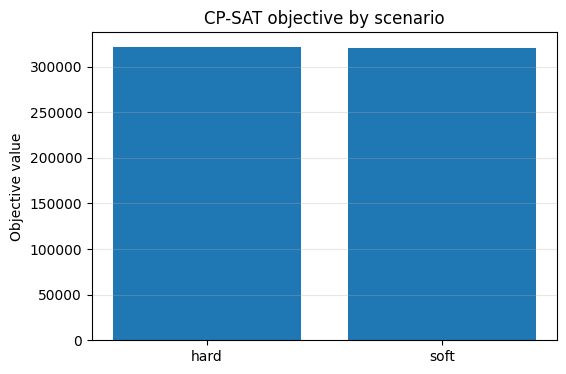

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(selected_revenue_df['scenario'], selected_revenue_df['objective_value'])
ax.set_title('CP-SAT objective by scenario')
ax.set_ylabel('Objective value')
ax.grid(True, axis='y', alpha=0.3)
plt.show()

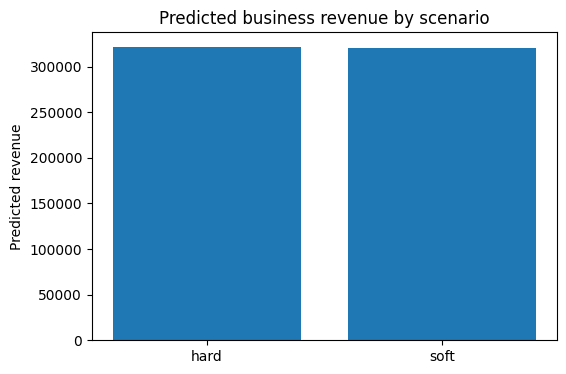

In [14]:
hard_selected_df = hard_result['selected_schedule_df'][[
    'cinema_id', 'hall_id', 'slot_id', 'movie_id',
    'show_datetime', 'end_datetime', 'format', 'hall_capacity', 'pred_revenue'
]].sort_values(['hall_id', 'show_datetime'])

hard_business_revenue = float(hard_selected_df['pred_revenue'].sum())

{
    'business_revenue_sum': hard_business_revenue,
    'solver_objective_value': hard_result['objective_value'],
    'num_selected': hard_result['num_selected'],
}

soft_selected_df = soft_result['selected_schedule_df'][[
    'cinema_id', 'hall_id', 'slot_id', 'movie_id',
    'show_datetime', 'end_datetime', 'format', 'hall_capacity', 'pred_revenue'
]].sort_values(['hall_id', 'show_datetime'])

soft_business_revenue = float(soft_selected_df['pred_revenue'].sum())

{
    'business_revenue_sum': soft_business_revenue,
    'solver_objective_value': soft_result['objective_value'],
    'num_selected': soft_result['num_selected'],
}

selected_revenue_df = pd.DataFrame(
    {
        'scenario': ['hard', 'soft'],
        'business_revenue_sum': [hard_business_revenue, soft_business_revenue],
        'solver_objective_value': [hard_result['objective_value'], soft_result['objective_value']],
        'num_selected': [hard_result['num_selected'], soft_result['num_selected']],
    }
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(selected_revenue_df['scenario'], selected_revenue_df['business_revenue_sum'])
ax.set_title('Predicted business revenue by scenario')
ax.set_ylabel('Predicted revenue')
plt.show()


In [15]:
import importlib

import boq_backend.solvers.qubo_builder as qubo_builder_module

importlib.reload(qubo_builder_module)
build_qubo_from_candidates = qubo_builder_module.build_qubo_from_candidates

qubo_var_index_map, qubo_Q, qubo_stats = build_qubo_from_candidates(
    universal_candidate_scored_df,
    hall_penalty=4e5,
    same_movie_penalty=8e4,
    cleaning_gap_min=20,
)

qubo_stats


{'n_variables': 32,
 'n_hall_conflicts': 104,
 'n_same_movie_cross_hall_conflicts': 30,
 'hall_penalty': 400000.0,
 'same_movie_penalty': 80000.0,
 'cleaning_gap_min': 20}

In [16]:
import json
from pathlib import Path

QUBO_DIR = PROJECT_ROOT / 'data' / 'qubo'
QUBO_DIR.mkdir(parents=True, exist_ok=True)

# 1) Сохраняем mapping var_index -> candidate_idx
qubo_mapping_path = QUBO_DIR / 'universal_qubo_var_index_map.json'
with qubo_mapping_path.open('w', encoding='utf-8') as f:
    json.dump(
        {int(k): int(v) for k, v in qubo_var_index_map.items()},
        f,
        ensure_ascii=False,
        indent=2,
    )

# 2) Сохраняем QUBO-матрицу как список (i, j, q_ij)
qubo_matrix_path = QUBO_DIR / 'universal_qubo_matrix.json'
with qubo_matrix_path.open('w', encoding='utf-8') as f:
    json.dump(
        [{'i': int(i), 'j': int(j), 'q': float(q)} for (i, j, q) in qubo_Q],
        f,
        ensure_ascii=False,
        indent=2,
    )

# 3) (опционально) сохраняем universal_candidate_scored_df как CSV
QUBO_CAND_PATH = QUBO_DIR / 'universal_candidate_scored.csv'
universal_candidate_scored_df.to_csv(QUBO_CAND_PATH, index=False)

{
    'mapping_path': str(qubo_mapping_path),
    'matrix_path': str(qubo_matrix_path),
    'candidate_path': str(QUBO_CAND_PATH),
    'num_variables': len(qubo_var_index_map),
    'num_qubo_terms': len(qubo_Q),
}


{'mapping_path': '/Users/mishatrubik/Desktop/QC/BOQ/data/qubo/universal_qubo_var_index_map.json',
 'matrix_path': '/Users/mishatrubik/Desktop/QC/BOQ/data/qubo/universal_qubo_matrix.json',
 'candidate_path': '/Users/mishatrubik/Desktop/QC/BOQ/data/qubo/universal_candidate_scored.csv',
 'num_variables': 32,
 'num_qubo_terms': 166}

In [17]:
def intervals_overlap(start_a, end_a, start_b, end_b):
    return max(start_a, start_b) < min(end_a, end_b)


def find_physical_hall_conflicts(schedule_df):
    work_df = schedule_df.copy().sort_values(
        ["cinema_id", "hall_id", "show_datetime"]
    )

    conflicts = []

    for (cinema_id, hall_id), group in work_df.groupby(["cinema_id", "hall_id"]):
        rows = list(group.itertuples())

        for i in range(len(rows)):
            a = rows[i]
            for j in range(i + 1, len(rows)):
                b = rows[j]

                # так как отсортировано по start time, можно рано выйти
                if a.end_datetime <= b.show_datetime:
                    break

                if intervals_overlap(
                    a.show_datetime,
                    a.end_datetime,
                    b.show_datetime,
                    b.end_datetime,
                ):
                    conflicts.append(
                        {
                            "cinema_id": cinema_id,
                            "hall_id": hall_id,
                            "candidate_idx_a": a.Index,
                            "candidate_idx_b": b.Index,
                            "movie_id_a": a.movie_id,
                            "movie_id_b": b.movie_id,
                            "start_a": a.show_datetime,
                            "end_a": a.end_datetime,
                            "start_b": b.show_datetime,
                            "end_b": b.end_datetime,
                            "pred_revenue_a": a.pred_revenue,
                            "pred_revenue_b": b.pred_revenue,
                        }
                    )

    return pd.DataFrame(conflicts)

hall_conflicts_cp = find_physical_hall_conflicts(soft_selected_df)
hall_conflicts_cp2 = find_physical_hall_conflicts(hard_selected_df)
print("Soft")
print("CP-SAT revenue:", soft_selected_df["pred_revenue"].sum())
print("CP-SAT shows:", len(soft_selected_df))
print("CP-SAT hall conflicts:", len(hall_conflicts_cp))
print("Hard")
print("CP-SAT revenue:", hard_selected_df["pred_revenue"].sum())
print("CP-SAT shows:", len(hard_selected_df))
print("CP-SAT hall conflicts:", len(hall_conflicts_cp2))


Soft
CP-SAT revenue: 320379.62
CP-SAT shows: 6
CP-SAT hall conflicts: 0
Hard
CP-SAT revenue: 321662.52999999997
CP-SAT shows: 6
CP-SAT hall conflicts: 0
